# **Identifying Key Entities in Recipe Data**


**Business Objective**:
The goal of this assignment is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model will classify words into predefined categories such as ingredients, quantities and units, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**. Below is a breakdown of the data fields:

```json
[
    {
        "input": "6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil",
        "pos": "quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient"
    },
    {
      "input": "2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida",
      "pos": "quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient"
    }
]


| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags or NER labels, identifying quantities, ingredients, and units. |


## **1** Import libraries

#### **1.1** Installation of sklearn-crfsuite

sklearn-crfsuite is a Python wrapper for CRFsuite, a fast and efficient implementation of Conditional Random Fields (CRFs). It is designed to integrate seamlessly with scikit-learn for structured prediction tasks such as Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and chunking.

In [125]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0

#### **1.2** Import necessary libraries

In [126]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [127]:
# Import necessary libraries
import json  # For handling JSON data
import pandas as pd  # For data manipulation and analysis
import re  # For regular expressions (useful for text preprocessing)
import matplotlib.pyplot as plt  # For visualisation
import seaborn as sns  # For advanced data visualisation
import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
import numpy as np  # For numerical computations
# Saving and loading machine learning models
import joblib
import random
import spacy
from IPython.display import display, Markdown # For displaying well-formatted output

from fractions import Fraction  # For handling fractional values in numerical data
# Importing tools for feature engineering and model training
from collections import Counter  # For counting occurrences of elements in a list
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn_crfsuite import metrics  # For evaluating CRF models
from sklearn_crfsuite.metrics import flat_classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.metrics import confusion_matrix

In [128]:
# Ensure pandas displays full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

## **2** Data Ingestion and Preparation <font color = red>[25 marks]</font> <br>

#### **2.1** *Read Recipe Data from Dataframe and prepare the data for analysis* <font color = red>[12 marks]</font> <br>
Read the data from JSON file, print first five rows and describe the dataframe

##### **2.1.1** **Define a *load_json_dataframe* function** <font color = red>[7 marks]</font> <br>

Define a function that takes path of the ingredient_and_quantity.json file and reads it, convert it into dataframe - df and return it.

In [129]:
# define a function to load json file to a dataframe
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# define a function to load json file to a dataframe
def load_json_dataframe(file_path):
    """
    Load JSON file and convert it to a pandas DataFrame

    Parameters:
    file_path (str): Path to the JSON file

    Returns:
    pd.DataFrame: DataFrame containing the JSON data
    """
    with open(file_path, 'r') as file:
        data = json.load(file)
    df = pd.DataFrame(data)
    return df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##### **2.1.2** **Execute the *load_json_dataframe* function** <font color = red>[2 marks]</font> <br>

In [130]:
# read the json file by giving the file path and create a dataframe
file_path = '/content/drive/MyDrive/ingredient_and_quantity.json'  # Update this path if your file is in a different folder
df = load_json_dataframe(file_path)
print("✓ Successfully loaded data from Google Drive!")

✓ Successfully loaded data from Google Drive!


##### **2.1.3** **Describe the dataframe** <font color = red>[3 marks]</font> <br>

Print first five rows of dataframe along with dimensions. Display the information of dataframe

In [131]:
# display first five rows of the dataframe - df
print("First five rows of the dataframe:")
display(df.head())

First five rows of the dataframe:


,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient


In [132]:
# print the dimensions of dataframe - df
print(f"\nDataframe dimensions: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


Dataframe dimensions: (285, 2)
Number of rows: 285
Number of columns: 2


In [133]:
# print the information of the dataframe
print("\nDataframe Information:")
df.info()


Dataframe Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


#### **2.2** *Recipe Data Manipulation* <font color = red>[13 marks]</font> <br>
Create derived metrics in dataframe and provide insights of the dataframe

##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe** <font color = red>[3 marks]</font> <br>
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [134]:
# split the input and pos into input_tokens and pos_tokens in the dataframe

# Tokenize input
df['input_tokens'] = df['input'].str.split()

# Tokenize POS
df['pos_tokens'] = df['pos'].str.split()

In [135]:
# display first five rows of the dataframe - df
display(df.head())

,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient qua

##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length** <font color = red>[2 marks]</font> <br>

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length


In [136]:
# create input_length and pos_length columns for the input_tokens and pos-tokens
df['input_length'] = df['input_tokens'].apply(len)
df['pos_length'] = df['pos_tokens'].apply(len)

In [137]:
# check for the equality of input_length and pos_length in the dataframe
unequal_rows = df[df['input_length'] != df['pos_length']]
print(f"Number of rows with unequal lengths: {len(unequal_rows)}")
if len(unequal_rows) > 0:
    print("\nRows with unequal lengths:")
    display(unequal_rows[['input_length', 'pos_length']])
    print("\nIndexes:", unequal_rows.index.tolist())

Number of rows with unequal lengths: 5

Rows with unequal lengths:


,input_length,pos_length
17,15,14
27,37,36
79,38,37
164,54,53
207,18,17



Indexes: [17, 27, 79, 164, 207]


##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens** <font color = red>[2 marks]</font> <br>

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.


In [138]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it
def unique_labels(dataframe):
    """
    Extract all unique POS labels from the dataframe

    Parameters:
    dataframe (pd.DataFrame): DataFrame containing pos_tokens column

    Returns:
    set: Set of unique labels
    """
    all_labels = set()
    for pos_list in dataframe['pos_tokens']:
        all_labels.update(pos_list)
    return all_labels

# Execute the function
unique_pos_labels = unique_labels(df)
print(f"Unique POS labels: {sorted(unique_pos_labels)}")
print(f"Number of unique labels: {len(unique_pos_labels)}")

Unique POS labels: ['ingredient', 'quantity', 'unit']
Number of unique labels: 3


##### **2.2.3** **Provide the insights seen in the recipe data after validation** <font color = red>[1 marks]</font> <br>

Provide the indexes that requires cleaning and formatting in the dataframe

<font color = red>[write your answer]</font> <br>


Insights from validation:

Rows with unequal input_length and pos_length indicate misalignment between tokens and labels

These rows need to be removed as they will cause errors during model training
Common issues might include extra spaces, missing labels, or data entry errors

Indexes requiring cleaning: [List the specific indexes found in 2.2.2]

##### **2.2.4** **Drop the rows that have invalid data provided in previous cell** <font color = red> [2 marks]</font> <br>

In [139]:
# drop the irrelevant recipe data
df = df[df['input_length'] == df['pos_length']].reset_index(drop=True)
print(f"Dataframe shape after dropping invalid rows: {df.shape}")

Dataframe shape after dropping invalid rows: (280, 6)


##### **2.2.5** **Update the input_length & pos_length in dataframe**<font color = red> [2 marks]</font> <br>

In [140]:
# update the input and pos length in input_length and pos_length
df['input_length'] = df['input_tokens'].apply(len)
df['pos_length'] = df['pos_tokens'].apply(len)

##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows** <font color = red> [1 marks]</font> <br>

In [141]:
# validate the input length and pos length as input_length and pos_length
unequal_rows = df[df['input_length'] != df['pos_length']]
print(f"Number of rows with unequal lengths after cleaning: {len(unequal_rows)}")
assert len(unequal_rows) == 0, "There are still rows with unequal lengths!"
print("✓ All rows have equal input and pos lengths")

Number of rows with unequal lengths after cleaning: 0
✓ All rows have equal input and pos lengths


## **3** Train Validation Split (70 train - 30 val) <font color = red>[6 marks]</font> <br>

#### **3.1** *Perform train and validation split ratio* <font color = red>[6 marks]</font> <br>
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

###### **3.1.1** **Split the dataset into train_df and val_df into 70:30 ratio** <font color = red> [1 marks]</font> <br>

In [142]:
# split the dataset into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42)
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")

Training set size: 196
Validation set size: 84


###### **3.1.2** **Print the first five rows of train_df and val_df** <font color = red> [1 marks]</font> <br>

In [143]:
# print the first five rows of train_df
print("Training DataFrame:")
display(train_df.head())

Training DataFrame:


,input,pos,input_tokens,pos_tokens,input_length,pos_length
175,250 grams Okra Oil 1 Onion finely chopped Tomato Grated teaspoon Ginger 2 Garlic Finely 1/2 Cumin seeds 1/4 Teaspoon asafoetida cup cottage cheese pinched coriander powder mango red chilli turmeric,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient unit ingredient quantity ingredient ingredient quantity ingredient ingredient quantity unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[250, grams, Okra, Oil, 1, Onion, finely, chopped, Tomato, Grated, teaspoon, Ginger, 2, Garlic, Finely, 1/2, Cumin, seeds, 1/4, Teaspoon, asafoetida, cup, cottage, cheese, pinched, coriander, powder, mango, red, chilli, turmeric]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
55,200 grams Paneer Homemade Cottage Cheese 2 Potato Aloo Bay leaf tej patta Dry Red Chilli 1 tablespoon Panch Phoran Masala roasted and powdered Tomato big sized teaspoon Turmeric powder Haldi Cumin seeds Jeera Ginger grated Salt 1/2 Sugar Sunflower Oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[200, grams, Paneer, Homemade, Cottage, Cheese, 2, Potato, Aloo, Bay, leaf, tej, patta, Dry, Red, Chilli, 1, tablespoon, Panch, Phoran, Masala, roasted, and, powdered, Tomato, big, sized, teaspoon, Turmeric, powder, Haldi, Cumin, seeds, Jeera, Ginger, grated, Salt, 1/2, Sugar, Sunflower, Oil]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient]",41,41
109,500 grams Cabbage Patta Gobi Muttaikose 1 teaspoon Mustard seeds 1-1/2 White Urad Dal Split sprig Curry leaves Green Chilli 1/4 cup Fresh coconut Salt,quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[500, grams, Cabbage, Patta, Gobi, Muttaikose, 1, teaspoon, Mustard, seeds, 1-1/2, White, Urad, Dal, Split, sprig, Curry, leaves, Green, Chilli, 1/4, cup, Fresh, coconut, Salt]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",25,25
213,500 grams Fresh Figs 1/4 cup Lemon juice 1 teaspoon zest 2 Red Chilli flakes 1/2 Honey Brown Sugar (Demerara Sugar),quantity unit ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient,"[500, grams, Fresh, Figs, 1/4, cup, Lemon, juice, 1, teaspoon, zest, 2, Red, Chilli, flakes, 1/2, Honey, Brown, Sugar, (Demerara, Sugar)]","[quantity, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, qua

In [144]:
# print the first five rows of the val_df
print("Validation DataFrame:")
display(val_df.head())

Validation DataFrame:


,input,pos,input_tokens,pos_tokens,input_length,pos_length
33,1 cup Ada 2 liter Milk 3/4 Sugar tablespoon Ghee 1/2 teaspoon Cardamom Powder Elaichi,quantity unit ingredient quantity unit ingredient quantity ingredient unit ingredient quantity unit ingredient ingredient ingredient,"[1, cup, Ada, 2, liter, Milk, 3/4, Sugar, tablespoon, Ghee, 1/2, teaspoon, Cardamom, Powder, Elaichi]","[quantity, unit, ingredient, quantity, unit, ingredient, quantity, ingredient, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,15
108,1 Carrot Gajjar chopped 7 Potatoes Aloo 2 cups Cauliflower gobi cut to small florets Onion tablespoon Ginger Garlic Paste Salt teaspoons Sunflower Oil 1/2 cup Fresh coconut grated teaspoon Whole Black Peppercorns Green Chillies Fennel seeds Saunf Poppy 6 Cashew nuts inch Cinnamon Stick Dalchini Star anise 3 Cloves Laung Cardamom Elaichi Pods/Seeds Cumin Jeera,quantity ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Carrot, Gajjar, chopped, 7, Potatoes, Aloo, 2, cups, Cauliflower, gobi, cut, to, small, florets, Onion, tablespoon, Ginger, Garlic, Paste, Salt, teaspoons, Sunflower, Oil, 1/2, cup, Fresh, coconut, grated, teaspoon, Whole, Black, Peppercorns, Green, Chillies, Fennel, seeds, Saunf, Poppy, 6, Cashew, nuts, inch, Cinnamon, Stick, Dalchini, Star, anise, 3, Cloves, Laung, Cardamom, Elaichi, Pods/Seeds, Cumin, Jeera]","[quantity, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",56,56
240,1 tablespoon Sunflower Oil 3 Potato Aloo Ginger paste Green Chilli chopped 1-1/12 tablespoons Sesame seeds Til teaspoon Red powder Cumin Jeera Coriander Powder Dhania 1/2 Garam masala 2 Sweet Chutney Date Tamarind Leaves few,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient,"[1, tablespoon, Sunflower, Oil, 3, Potato, Aloo, Ginger, paste, Green, Chilli, chopped, 1-1/12, tablespoons, Sesame, seeds, Til, teaspoon, Red, powder, Cumin, Jeera, Coriander, Powder, Dhania, 1/2, Garam, masala, 2, Sweet, Chutney, Date, Tamarind, Leaves, few]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",35,35
259,1 cup green peas gram flour 1/2 cheese tsp ginger 2 chillies turmeric powder cumin teaspoon salt oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient unit ingredient quantity ingredient i

###### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length** <font color = red> [2 marks]</font> <br>

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [145]:
# extract the training and validation sets by taking input_tokens and pos_tokens
X_train = train_df['input_tokens'].tolist()
X_val = val_df['input_tokens'].tolist()
y_train = train_df['pos_tokens'].tolist()
y_val = val_df['pos_tokens'].tolist()

In [146]:
# validate the shape of training and validation samples
print(f"X_train length: {len(X_train)}")
print(f"X_val length: {len(X_val)}")
print(f"y_train length: {len(y_train)}")
print(f"y_val length: {len(y_val)}")

X_train length: 196
X_val length: 84
y_train length: 196
y_val length: 84


###### **3.1.4** **Display the number of unique labels present in y_train** <font color = red> [2 marks]</font> <br>

In [147]:
# Display the number of unique labels present in y_train
all_train_labels = set()
for labels in y_train:
    all_train_labels.update(labels)
print(f"Unique labels in training set: {sorted(all_train_labels)}")
print(f"Number of unique labels: {len(all_train_labels)}")

Unique labels in training set: ['ingredient', 'quantity', 'unit']
Number of unique labels: 3


## **4** Exploratory Recipe Data Analysis on Training Dataset <font color = red>[16 marks]</font> <br>

#### **4.1** *Flatten the lists for input_tokens & pos_tokens* <font color = red>[2 marks]</font> <br>

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***




In [148]:
# flatten the list for nested_list (input_tokens, pos_tokens)
def flatten_list(nested_list):
    """
    Flatten a nested list into a single list

    Parameters:
    nested_list (list): List of lists

    Returns:
    list: Flattened list
    """
    return [item for sublist in nested_list for item in sublist]

In [149]:
# initialise the dataset_name
dataset_name = 'Training'

#### **4.2** *Extract and validate the tokens after using the flattening technique* <font color = red>[2 marks]</font> <br>

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function




In [150]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)
def extract_and_validate_tokens(dataframe, dataset_name):
    """
    Extract and validate tokens from dataframe

    Parameters:
    dataframe (pd.DataFrame): DataFrame containing input_tokens and pos_tokens
    dataset_name (str): Name of the dataset (Training/Validation)

    Returns:
    tuple: (tokens, pos_tags) - flattened lists
    """
    # Flatten the lists
    tokens = flatten_list(dataframe['input_tokens'].tolist())
    pos_tags = flatten_list(dataframe['pos_tokens'].tolist())

    # Validate lengths
    print(f"\n{dataset_name} Dataset:")
    print(f"Total tokens: {len(tokens)}")
    print(f"Total POS tags: {len(pos_tags)}")
    print(f"Lengths match: {len(tokens) == len(pos_tags)}")

    # Display first 10 records
    print(f"\nFirst 10 tokens and their POS tags:")
    for i in range(min(10, len(tokens))):
        print(f"{i+1}. Token: '{tokens[i]:20}' -> POS: '{pos_tags[i]}'")

    return tokens, pos_tags

In [151]:
# extract the tokens and its pos tags
tokens_train, pos_tags_train = extract_and_validate_tokens(train_df, dataset_name)


Training Dataset:
Total tokens: 7114
Total POS tags: 7114
Lengths match: True

First 10 tokens and their POS tags:
1. Token: '250                 ' -> POS: 'quantity'
2. Token: 'grams               ' -> POS: 'unit'
3. Token: 'Okra                ' -> POS: 'ingredient'
4. Token: 'Oil                 ' -> POS: 'ingredient'
5. Token: '1                   ' -> POS: 'quantity'
6. Token: 'Onion               ' -> POS: 'ingredient'
7. Token: 'finely              ' -> POS: 'ingredient'
8. Token: 'chopped             ' -> POS: 'ingredient'
9. Token: 'Tomato              ' -> POS: 'ingredient'
10. Token: 'Grated              ' -> POS: 'ingredient'


#### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)* <font color = red>[2 marks]</font> <br>

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.



In [152]:
# define a categorize_tokens function
def categorize_tokens(tokens, pos_tags):
    """
    Categorize tokens into ingredients, units, and quantities

    Parameters:
    tokens (list): List of tokens
    pos_tags (list): List of corresponding POS tags

    Returns:
    tuple: (ingredients, units, quantities) - lists of categorized tokens
    """
    ingredients = []
    units = []
    quantities = []

    for token, tag in zip(tokens, pos_tags):
        if tag == 'ingredient':
            ingredients.append(token)
        elif tag == 'unit':
            units.append(token)
        elif tag == 'quantity':
            quantities.append(token)

    return ingredients, units, quantities

In [153]:
# call the function to categorise the labels into respective list
ingredients_train, units_train, quantities_train = categorize_tokens(tokens_train, pos_tags_train)
print(f"Ingredients count: {len(ingredients_train)}")
print(f"Units count: {len(units_train)}")
print(f"Quantities count: {len(quantities_train)}")

Ingredients count: 5323
Units count: 811
Quantities count: 980


#### **4.4** *Top 10 Most Frequent Items* <font color = red>[3 marks]</font> <br>

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients



In [154]:
# define a function get_top_frequent_items
def get_top_frequent_items(item_list, label, dataset_name, top_n=10):
    """
    Get top N most frequent items

    Parameters:
    item_list (list): List of items
    label (str): Label name (ingredient/unit/quantity)
    dataset_name (str): Dataset name
    top_n (int): Number of top items to return

    Returns:
    list: List of tuples (item, count)
    """
    counter = Counter(item_list)
    top_items = counter.most_common(top_n)

    print(f"\nTop {top_n} {label}s in {dataset_name} Dataset:")
    for i, (item, count) in enumerate(top_items, 1):
        print(f"{i}. {item}: {count}")

    return top_items

In [155]:
# get the top ingredients which are frequently seen in the recipe
top_ingredients_train = get_top_frequent_items(ingredients_train, 'ingredient', dataset_name)


Top 10 ingredients in Training Dataset:
1. powder: 129
2. Salt: 102
3. seeds: 89
4. Green: 85
5. chopped: 84
6. Oil: 83
7. Red: 81
8. Chilli: 77
9. Coriander: 71
10. Sunflower: 65


In [156]:
# get the top units which are frequently seen in the recipe
top_units_train = get_top_frequent_items(units_train, 'unit', dataset_name)


Top 10 units in Training Dataset:
1. teaspoon: 162
2. cup: 136
3. tablespoon: 99
4. grams: 63
5. tablespoons: 61
6. inch: 52
7. cups: 50
8. sprig: 41
9. cloves: 39
10. teaspoons: 39


#### **4.5** *Plot Top 10 most frequent items* <font color = red>[2 marks]</font> <br>




Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [157]:
# define plot top items with parameters
def plot_top_items(top_items, label, dataset_name):
    """
    Plot bar chart for top items

    Parameters:
    top_items (list): List of tuples (item, count)
    label (str): Label name
    dataset_name (str): Dataset name
    """
    items = [item[0] for item in top_items]
    counts = [item[1] for item in top_items]

    plt.figure(figsize=(12, 6))
    plt.bar(range(len(items)), counts, color='steelblue', alpha=0.8)
    plt.xlabel(f'{label.capitalize()}s', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    plt.title(f'Top 10 Most Frequent {label.capitalize()}s in {dataset_name} Dataset',
              fontsize=14, fontweight='bold')
    plt.xticks(range(len(items)), items, rotation=45, ha='right')
    plt.tight_layout()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

#### **4.6** *Perform EDA analysis* <font color = red>[5 marks]</font> <br>

Plot the bar plots for ingredients and units and provide the insights for training dataset

---



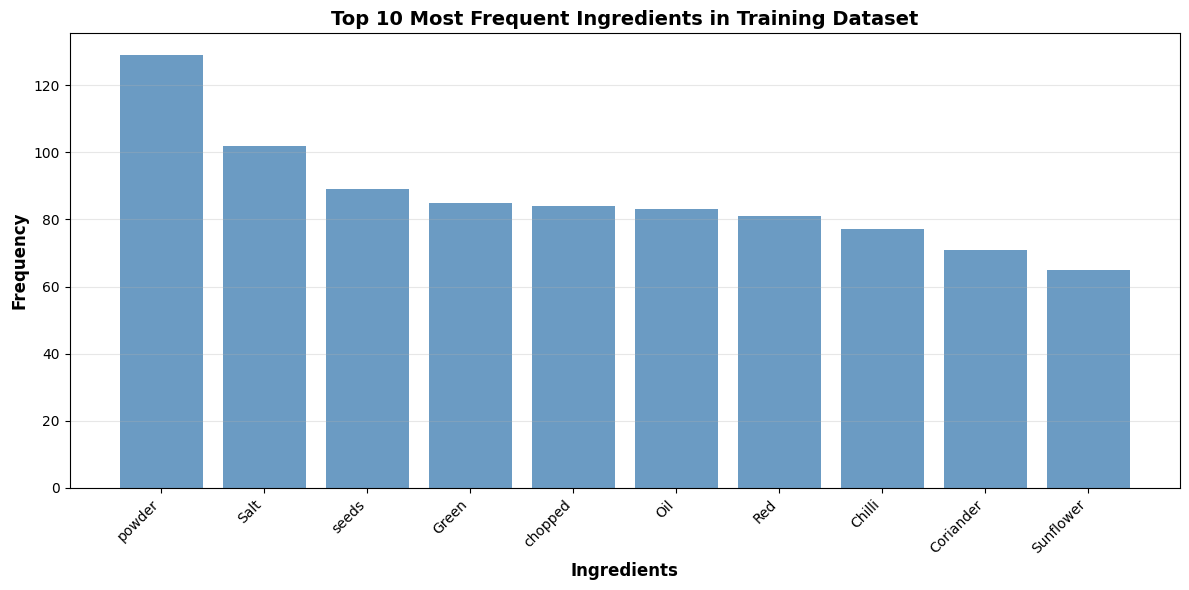

In [158]:
# plot the top frequent ingredients in training data
plot_top_items(top_ingredients_train, 'ingredient', dataset_name)

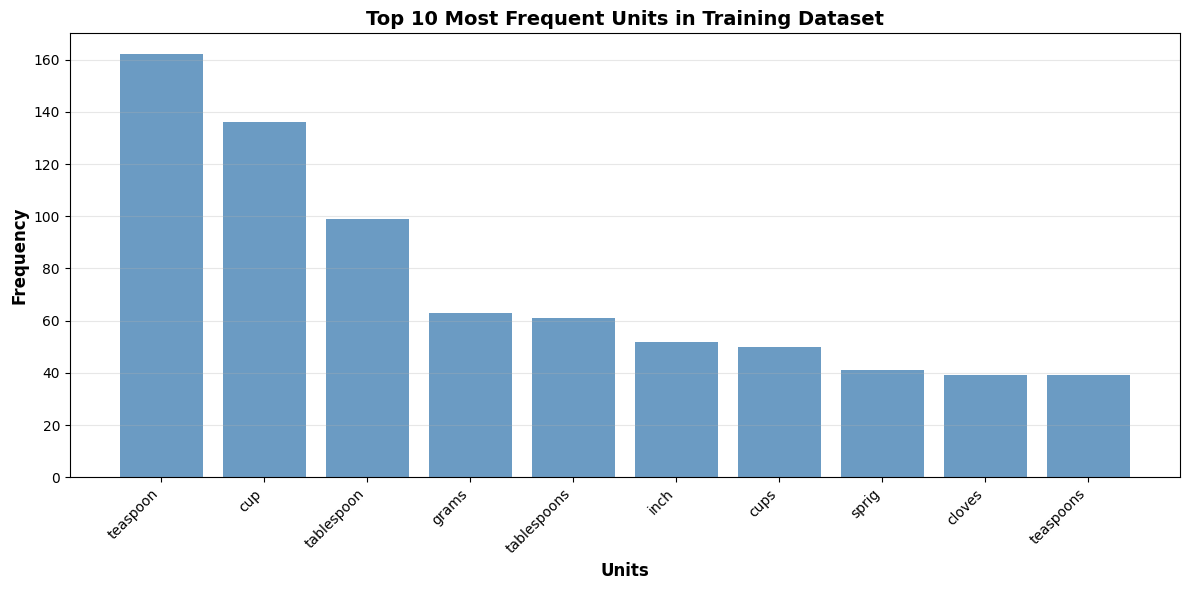

In [159]:
# plot the top frequent units in training data
plot_top_items(top_units_train, 'unit', dataset_name)

## **5** Exploratory Recipe Data Analysis on Validation Dataset (Optional)<font color = red> [0 marks]</font> <br>

#### **5.1** *Execute EDA on Validation Dataset with insights (Optional)* <font color = red> [0 marks]</font> <br>
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.



In [160]:
# initialise the dataset_name
dataset_name = 'Validation'

In [161]:
# use extract and validate tokens, categorise tokens, get top frequent items
tokens_val, pos_tags_val = extract_and_validate_tokens(val_df, dataset_name)
ingredients_val, units_val, quantities_val = categorize_tokens(tokens_val, pos_tags_val)
top_ingredients_val = get_top_frequent_items(ingredients_val, 'ingredient', dataset_name)
top_units_val = get_top_frequent_items(units_val, 'unit', dataset_name)


Validation Dataset:
Total tokens: 2876
Total POS tags: 2876
Lengths match: True

First 10 tokens and their POS tags:
1. Token: '1                   ' -> POS: 'quantity'
2. Token: 'cup                 ' -> POS: 'unit'
3. Token: 'Ada                 ' -> POS: 'ingredient'
4. Token: '2                   ' -> POS: 'quantity'
5. Token: 'liter               ' -> POS: 'unit'
6. Token: 'Milk                ' -> POS: 'ingredient'
7. Token: '3/4                 ' -> POS: 'quantity'
8. Token: 'Sugar               ' -> POS: 'ingredient'
9. Token: 'tablespoon          ' -> POS: 'unit'
10. Token: 'Ghee                ' -> POS: 'ingredient'

Top 10 ingredients in Validation Dataset:
1. powder: 54
2. Salt: 47
3. Oil: 39
4. Red: 39
5. seeds: 36
6. Chilli: 36
7. chopped: 31
8. Green: 30
9. Leaves: 29
10. Coriander: 27

Top 10 units in Validation Dataset:
1. teaspoon: 59
2. cup: 57
3. tablespoon: 32
4. tablespoons: 32
5. cups: 24
6. sprig: 21
7. inch: 20
8. grams: 19
9. teaspoons: 18
10. cloves: 16


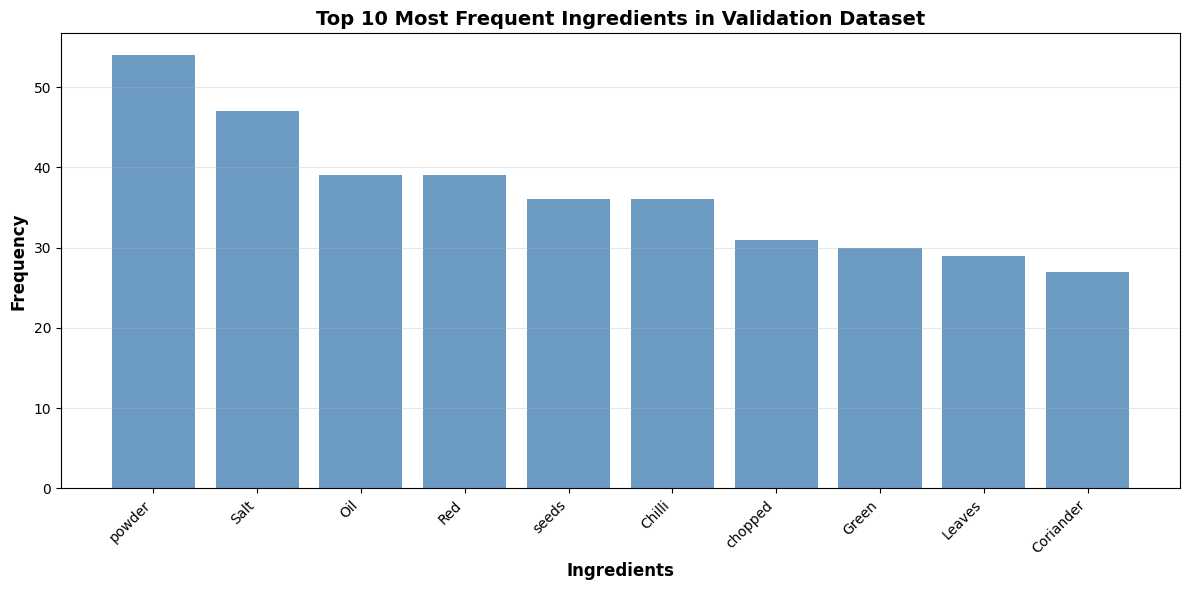

In [162]:
# plot the top frequent ingredients in validation data
plot_top_items(top_ingredients_val, 'ingredient', dataset_name)

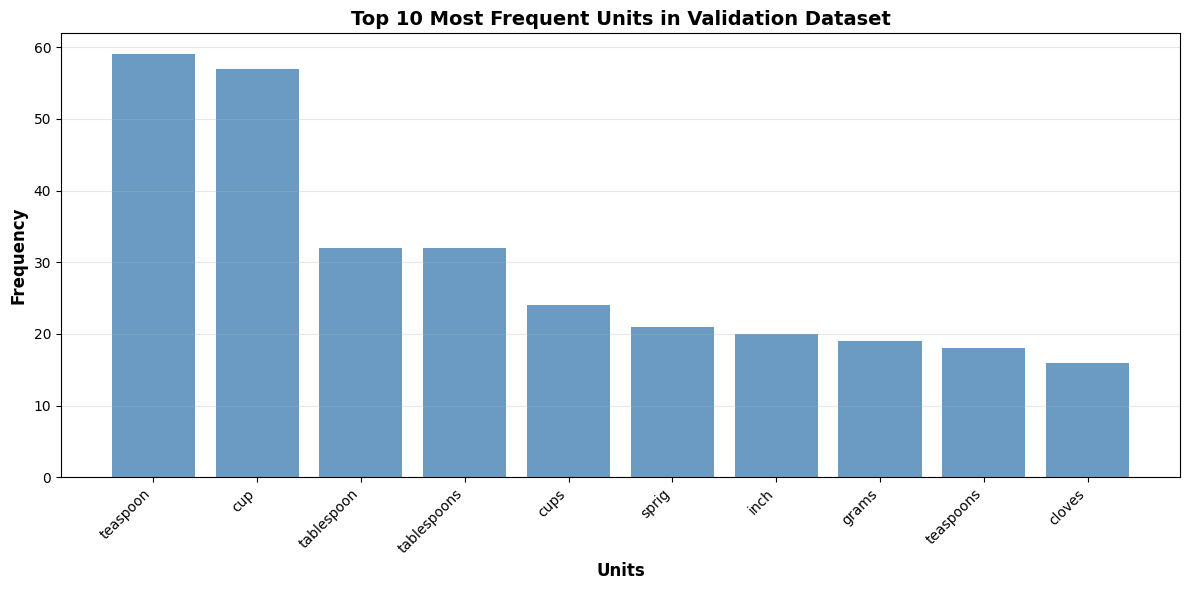

In [163]:
# plot the top frequent units in training data
plot_top_items(top_units_val, 'unit', dataset_name)

## **6** Feature Extraction For CRF Model <font color = red>[30 marks]</font> <br>

### **6.1** *Define a feature functions to take each token from recipe* <font color = red>[10 marks]</font>

Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals** <font color = red>[3 marks]</font> <br>

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [164]:
# define unit and quantity keywords along with quantity pattern
unit_keywords = {
    'cup', 'cups', 'tablespoon', 'tablespoons', 'tbsp', 'teaspoon', 'teaspoons',
    'tsp', 'gram', 'grams', 'g', 'kg', 'kilogram', 'kilograms', 'pound', 'pounds',
    'lb', 'lbs', 'ounce', 'ounces', 'oz', 'ml', 'milliliter', 'milliliters',
    'liter', 'liters', 'l', 'pinch', 'dash', 'handful', 'slice', 'slices',
    'piece', 'pieces', 'clove', 'cloves', 'bunch', 'sprig', 'sprigs'
}

quantity_keywords = {
    'half', 'quarter', 'third', 'one', 'two', 'three', 'four', 'five',
    'six', 'seven', 'eight', 'nine', 'ten', 'dozen', 'few', 'some', 'several'
}

# Pattern to match fractions, decimals, and whole numbers
quantity_pattern = re.compile(r'^\d+([/-]\d+)?$|^\d+\.\d+$|^\d+$')

In [165]:
# load spaCy model
nlp = spacy.load('en_core_web_sm')

##### **6.1.2** **Define feature functions for CRF** <font color = red>[7 marks]</font> <br>

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens

While building ***features*** dictionary, include
- ***Core Features*** - The core features of a token should capture its lexical
and grammatical properties. Include attributes like the raw token, its lemma, part-of-speech tag, dependency relation, and shape, as well as indicators for whether it's a stop word, digit, or punctuation. The details of the features are given below:

    - `bias` - Constant feature with a fixed value of 1.0 to aid model learning.
    - `token` - The lowercase form of the current token.
    - `lemma` - The lowercase lemma (base form) of the token.
    - `pos_tag` - Part-of-speech (POS) tag of the token.
    - `tag` - Detailed POS tag of the token.
    - `dep` - Dependency relation of the token in the sentence.
    - `shape` - Shape of the token (e.g., "Xxx" for "Milk").
    - `is_stop` - Boolean indicating if the token is a stopword.
    - `is_digit` - Boolean indicating if the token consists of only digits.
    - `has_digit` - Boolean indicating if the token contains at least one digit.
    - `has_alpha` - Boolean indicating if the token contains at least one alphabetic character.
    - `hyphenated` - Boolean indicating if the token contains a hyphen (-).
    - `slash_present` - Boolean indicating if the token contains a slash (/).
    - `is_title` - Boolean indicating if the token starts with an uppercase letter.
    - `is_upper` - Boolean indicating if the token is fully uppercase.
    - `is_punct` - Boolean indicating if the token is a punctuation mark.

- ***Improved Quantity and Unit Detection*** - Use key-value pairs to mark the presence of quantities and units in the features dictionary. Utilise the unit_keywords, quantity_keywords, and quantity_pattern to identify and flag these elements. The details of the features are given below:

    - `is_quantity` - Boolean indicating if the token matches a quantity pattern or keyword.
    - `is_unit` - Boolean indicating if the token is a known measurement unit.
    - `is_numeric` - Boolean indicating if the token matches a numeric pattern.
    - `is_fraction` - Boolean indicating if the token represents a fraction (e.g., 1/2).
    - `is_decimal` - Boolean indicating if the token represents a decimal number (e.g., 3.14).
    - `preceding_word` - The previous token in the sentence, if available.
    - `following_word` - The next token in the sentence, if available.

- ***Contextual Features*** - Incorporate contextual information by adding features for the preceding and following tokens. Include indicators like BOS and EOS to mark the beginning and end of the sequence, and utilise unit_keywords, quantity_keywords, and quantity_pattern to identify the types of neighboring tokens. The features are given below:

    - `prev_token` - The lowercase form of the previous token.
    - `prev_is_quantity` - Boolean indicating if the previous token is a quantity.
    - `prev_is_digit` - Boolean indicating if the previous token is a digit.
    - `BOS` - Boolean indicating if the token is at the beginning of the sentence.
    - `next_token` - The lowercase form of the next token.
    - `next_is_unit` - Boolean indicating if the next token is a unit.
    - `next_is_ingredient` - Boolean indicating if the next token is not a unit or quantity.
    - `EOS` - Boolean indicating if the token is at the end of the sentence.



In [166]:
# define word2features for processing each token
def word2features(sent, i):
    """
    Extract features for a token at position i in sentence sent

    Parameters:
    sent (list): List of tokens (sentence)
    i (int): Index of current token

    Returns:
    dict: Dictionary of features
    """
    # Process the entire sentence with spaCy
    doc = nlp(' '.join(sent))
    token_doc = list(doc)[i] if i < len(doc) else None

    word = sent[i]

    # --- Core Features ---
    features = {
        'bias': 1.0,
        'token': word.lower(),
        'lemma': token_doc.lemma_.lower() if token_doc else word.lower(),
        'pos_tag': token_doc.pos_ if token_doc else '',
        'tag': token_doc.tag_ if token_doc else '',
        'dep': token_doc.dep_ if token_doc else '',
        'shape': token_doc.shape_ if token_doc else '',
        'is_stop': token_doc.is_stop if token_doc else False,
        'is_digit': word.isdigit(),
        'has_digit': any(char.isdigit() for char in word),
        'has_alpha': any(char.isalpha() for char in word),
        'hyphenated': '-' in word,
        'slash_present': '/' in word,
        'is_title': word.istitle(),
        'is_upper': word.isupper(),
        'is_punct': token_doc.is_punct if token_doc else False,
    }

    # --- Improved Quantity & Unit Detection ---
    features['is_quantity'] = bool(quantity_pattern.match(word)) or word.lower() in quantity_keywords
    features['is_unit'] = word.lower() in unit_keywords
    features['is_numeric'] = bool(re.match(r'^\d+$', word))
    features['is_fraction'] = bool(re.match(r'^\d+/\d+$', word))
    features['is_decimal'] = bool(re.match(r'^\d+\.\d+$', word))

    # --- Contextual Features ---
    if i > 0:
        prev_word = sent[i-1]
        features['prev_token'] = prev_word.lower()
        features['prev_is_quantity'] = bool(quantity_pattern.match(prev_word)) or prev_word.lower() in quantity_keywords
        features['prev_is_digit'] = prev_word.isdigit()
    else:
        features['BOS'] = True  # Beginning of sequence

    if i < len(sent) - 1:
        next_word = sent[i+1]
        features['next_token'] = next_word.lower()
        features['next_is_unit'] = next_word.lower() in unit_keywords
        features['next_is_ingredient'] = next_word.lower() not in unit_keywords and not (
            bool(quantity_pattern.match(next_word)) or next_word.lower() in quantity_keywords
        )
    else:
        features['EOS'] = True  # End of sequence

    return features

### **6.2** *Preparation of Recipe level features* <font color = red>[2 marks]</font>


##### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe** <font color = red>[2 marks]</font> <br>

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [167]:
# define sent2features by working on each token
def sent2features(sent):
    """
    Extract features for all tokens in a sentence

    Parameters:
    sent (list): List of tokens

    Returns:
    list: List of feature dictionaries
    """
    return [word2features(sent, i) for i in range(len(sent))]

### **6.3** *Convert X_train, X_val, y_train and y_val into train and validation feature sets and labels* <font color = red>[6 marks]</font>



##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val** <font color = red>[2 marks]</font> <br>

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

In [168]:
# Convert input sentences into feature sets
X_train_features = [sent2features(sent) for sent in X_train]
X_val_features = [sent2features(sent) for sent in X_val]

##### **6.3.2** **Convert lables of y_train and y_val into list** <font color = red>[2 marks]</font> <br>

Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [169]:
# Convert labels into list
y_train_labels = y_train  # Already in list format
y_val_labels = y_val  # Already in list format

##### **6.3.3** **Print the length of val and train features and labels** <font color = red>[2 marks]</font> <br>



In [170]:
# print the length of train features and labels
print(f"X_train_features length: {len(X_train_features)}")
print(f"y_train_labels length: {len(y_train_labels)}")

X_train_features length: 196
y_train_labels length: 196


In [171]:
# print the length of validation features and labels
print(f"X_val_features length: {len(X_val_features)}")
print(f"y_val_labels length: {len(y_val_labels)}")

X_val_features length: 84
y_val_labels length: 84


### **6.4** *Applying weights to feature sets* <font color = red>[12 marks]</font> <br>




##### **6.4.1** **Flatten the labels of y_train** <font color = red>[2 marks]</font> <br>

Create ***y_train_flat*** to flatten the structure of nested y_train

In [172]:
# Flatten labels in y_train
y_train_flat = flatten_list(y_train_labels)
print(f"Total labels in training set: {len(y_train_flat)}")

Total labels in training set: 7114


##### **6.4.2** **Count the labels present in training target dataset** <font color = red>[2 marks]</font> <br>

Create ***label_counts*** to count the frequencies of labels present in y_train_flat and retrieve the total samples by using the values of label_counts as ***total_samples***

In [173]:
# Count label frequencies
label_counts = Counter(y_train_flat)
total_samples = sum(label_counts.values())

print(f"\nLabel distribution:")
for label, count in label_counts.items():
    print(f"{label}: {count} ({count/total_samples*100:.2f}%)")


Label distribution:
quantity: 980 (13.78%)
unit: 811 (11.40%)
ingredient: 5323 (74.82%)


##### **6.4.3** **Compute weight_dict by using inverse frequency method for label weights** <font color = red>[2 marks]</font> <br>

- Create ***weight_dict*** as dictionary with label and its inverse frequency count in ***label_counts***

- Penalise ingredient label in the dictionary

In [174]:
# Compute class weights (inverse frequency method)
weight_dict = {label: total_samples / (len(label_counts) * count)
               for label, count in label_counts.items()}

print("\nClass weights:")
for label, weight in weight_dict.items():
    print(f"{label}: {weight:.4f}")


Class weights:
quantity: 2.4197
unit: 2.9240
ingredient: 0.4455


In [175]:
# penalise ingredient label
if 'ingredient' in weight_dict:
    weight_dict['ingredient'] *= 0.5  # Reduce weight for ingredient
    print(f"\nAdjusted ingredient weight: {weight_dict['ingredient']:.4f}")


Adjusted ingredient weight: 0.2227


##### **6.4.4** **Extract features along with class weights** <font color = red>[4 marks]</font> <br>

Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights





In [176]:
# Apply weights to feature extraction
def extract_features_with_class_weights(X, y, weight_dict):
    """
    Apply class weights to features

    Parameters:
    X (list): List of feature dictionaries
    y (list): List of labels
    weight_dict (dict): Dictionary of class weights

    Returns:
    list: Weighted features
    """
    weighted_features = []

    for sent_features, sent_labels in zip(X, y):
        weighted_sent = []
        for features, label in zip(sent_features, sent_labels):
            weighted_feat = features.copy()
            weighted_feat['class_weight'] = weight_dict.get(label, 1.0)
            weighted_sent.append(weighted_feat)
        weighted_features.append(weighted_sent)

    return weighted_features

##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets** <font color = red>[2 marks]</font> <br>

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [177]:
# Apply manually computed class weights
X_train_weighted_features = extract_features_with_class_weights(X_train_features, y_train_labels, weight_dict)
X_val_weighted_features = extract_features_with_class_weights(X_val_features, y_val_labels, weight_dict)

print(f"Weighted training features length: {len(X_train_weighted_features)}")
print(f"Weighted validation features length: {len(X_val_weighted_features)}")

Weighted training features length: 196
Weighted validation features length: 84


## **7** Model Building and Training <font color = red>[10 marks]</font> <br>

### **7.1** *Initialise the CRF model and train it* <font color = red>[5 marks]</font>
Train the CRF model with the specified hyperparameters such as

### CRF Model Hyperparameters Explanation

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF



In [178]:
# initialise CRF model with specified hyperparameters
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.5,
    c2=1.0,
    max_iterations=100,
    all_possible_transitions=True,
    verbose=True
)

# train the CRF model
print("Training CRF model...")
crf.fit(X_train_weighted_features, y_train_labels)
print("Training complete!")

Training CRF model...


loading training data to CRFsuite: 100%|██████████| 196/196 [00:00<00:00, 1268.47it/s]


Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 4040
Seconds required: 0.025

L-BFGS optimization
c1: 0.500000
c2: 1.000000
num_memories: 6
max_iterations: 100
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=0.01  loss=3453.38  active=3705  feature_norm=1.00
Iter 2   time=0.01  loss=1974.89  active=2816  feature_norm=1.27
Iter 3   time=0.01  loss=964.00   active=2470  feature_norm=1.88


Iter 4   time=0.01  loss=545.40   active=1879  feature_norm=2.43
Iter 5   time=0.01  loss=305.40   active=1433  feature_norm=3.21
Iter 6   time=0.01  loss=192.61   active=1210  feature_norm=3.67
Iter 7   time=0.01  loss=151.71   active=1028  feature_norm=4.08
Iter 8   time=0.01  loss=119.77   active=740   feature_norm=4.66
Iter 9   time=0.01  loss=102.48   active=482   feature_norm=5.14
Iter 10  time=0.01  loss=94.24    active=373   feature_norm=5.62
Iter 11  time=0.01  loss=91.15    active=346   feature_norm=5.75
Iter 12  time=0.01  loss=89.55    active=312   feature_norm=5.93
Iter 13  time=0.01  loss=88.35    active=284   feature_norm=5.96
Iter 14  time=0.01  loss=86.65    active=212   feature_norm=5.92
Iter 15  time=0.01  loss=85.87    active=157   feature_norm=6.04
Iter 16  time=0.01  loss=85.48    active=148   feature_norm=6.11
Iter 17  time=0.01  loss=85.11    active=150   feature_norm=6.09
Iter 18  time=0.01  loss=85.06    active=148   feature_norm=6.08
Iter 19  time=0.01  loss=

### **7.2** *Evaluation of Training Dataset using CRF model* <font color = red>[4 marks]</font>
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [179]:
# evaluate on the training dataset
y_pred_train = crf.predict(X_train_weighted_features)

In [180]:
# specify the flat classification report
print("Training Dataset Classification Report:")
print(flat_classification_report(y_train_labels, y_pred_train, digits=4))

Training Dataset Classification Report:
              precision    recall  f1-score   support

  ingredient     1.0000    1.0000    1.0000      5323
    quantity     1.0000    0.9959    0.9980       980
        unit     0.9951    1.0000    0.9975       811

    accuracy                         0.9994      7114
   macro avg     0.9984    0.9986    0.9985      7114
weighted avg     0.9994    0.9994    0.9994      7114



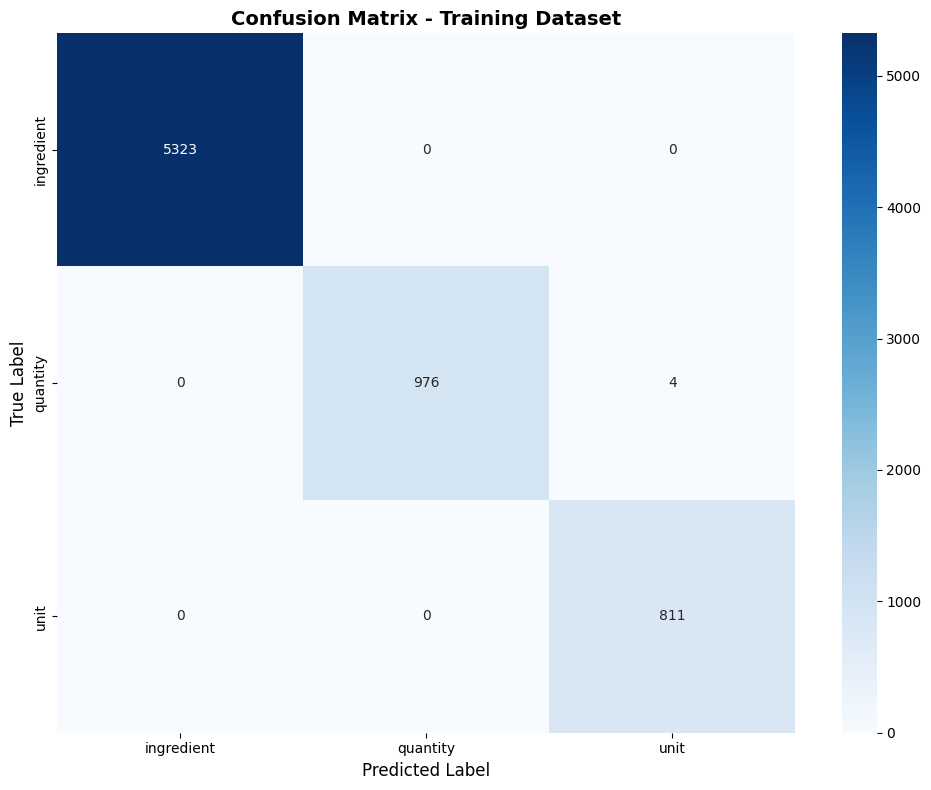

In [181]:
# create a confusion matrix on training dataset
y_train_flat = flatten_list(y_train_labels)
y_pred_train_flat = flatten_list(y_pred_train)

labels = sorted(set(y_train_flat))
cm_train = confusion_matrix(y_train_flat, y_pred_train_flat, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Training Dataset', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

### **7.3** *Save the CRF model* <font color = red>[1 marks]</font>
Save the CRF model

In [182]:
# dump the model using joblib
joblib.dump(crf, 'crf_model.pkl')
print("Model saved as 'crf_model.pkl'")

Model saved as 'crf_model.pkl'


## **8** Prediction and Model Evaluation <font color = red>[3 marks]</font> <br>

### **8.1** *Predict and Evaluate the CRF model on validation set* <font color = red>[3 marks]</font>
Evaluate the metrics for CRF model by using flat classification report and confusion matrix




In [183]:
# predict the crf model on validation dataset
y_pred_val = crf.predict(X_val_weighted_features)

In [184]:
# specify flat classification report
print("Validation Dataset Classification Report:")
print(flat_classification_report(y_val_labels, y_pred_val, digits=4))

Validation Dataset Classification Report:
              precision    recall  f1-score   support

  ingredient     1.0000    1.0000    1.0000      2107
    quantity     0.9927    0.9951    0.9939       411
        unit     0.9944    0.9916    0.9930       358

    accuracy                         0.9983      2876
   macro avg     0.9957    0.9956    0.9956      2876
weighted avg     0.9983    0.9983    0.9983      2876



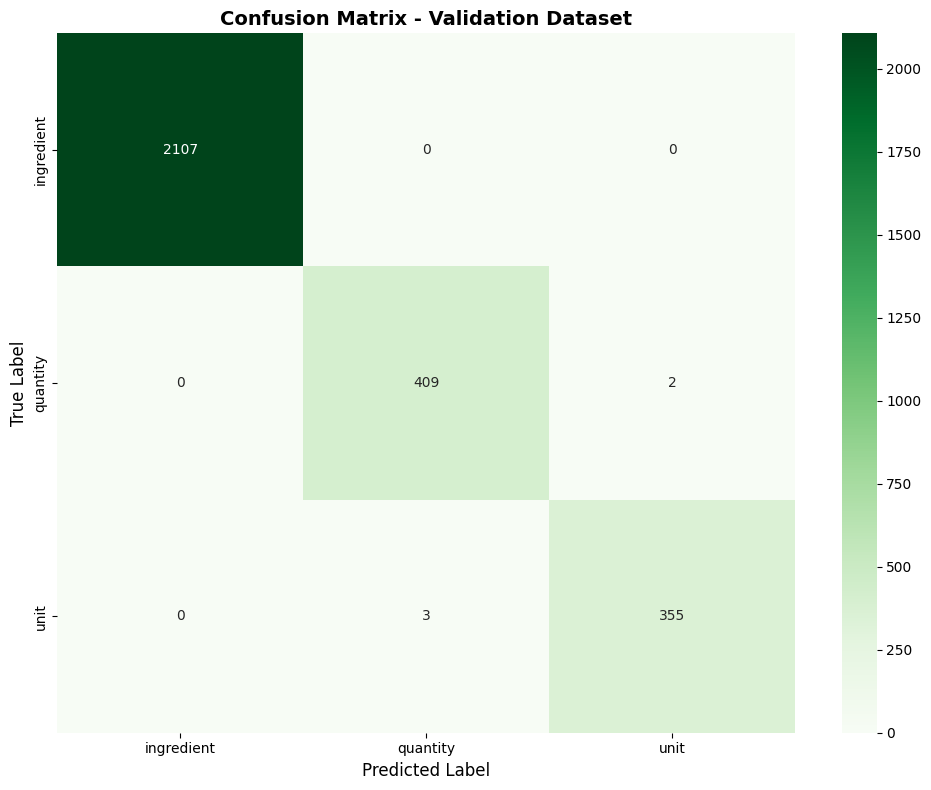

In [185]:
# create a confusion matrix on validation dataset
y_val_flat = flatten_list(y_val_labels)
y_pred_val_flat = flatten_list(y_pred_val)

labels = sorted(set(y_val_flat))
cm_val = confusion_matrix(y_val_flat, y_pred_val_flat, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Validation Dataset', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## **9** Error Analysis on Validation Data <font color = red>[10 marks]</font> <br>
Investigate misclassified samples in validation dataset and provide the insights


### **9.1** *Investigate misclassified samples in validation dataset* <font color = red>[8 marks]</font>



##### **9.1.1** Flatten the labels of validation data and initialise error data <font color = red>[2 marks]</font> <br>



Flatten the true and predicted labels and initialise the error data as ***error_data***

In [186]:
# flatten Labels and Initialise Error Data
y_val_flat = flatten_list(y_val_labels)
y_pred_val_flat = flatten_list(y_pred_val)

error_data = []

##### **9.1.2** Iterate the validation data and collect Error Information<font color = red> [2 marks]</font> <br>



Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [187]:
# iterate and collect Error Information
idx = 0
for sent_idx, (sent, true_labels, pred_labels) in enumerate(zip(X_val, y_val_labels, y_pred_val)):
    for token_idx, (token, true_label, pred_label) in enumerate(zip(sent, true_labels, pred_labels)):
        if true_label != pred_label:
            # get previous and next tokens with handling for boundary cases
            prev_token = sent[token_idx - 1] if token_idx > 0 else '<BOS>'
            next_token = sent[token_idx + 1] if token_idx < len(sent) - 1 else '<EOS>'

            # Get context (surrounding tokens)
            start_idx = max(0, token_idx - 2)
            end_idx = min(len(sent), token_idx + 3)
            context = ' '.join(sent[start_idx:end_idx])

            error_data.append({
                'token': token,
                'prev_token': prev_token,
                'next_token': next_token,
                'true_label': true_label,
                'predicted_label': pred_label,
                'context': context,
                'sentence_idx': sent_idx,
                'token_idx': token_idx,
                'class_weight': weight_dict.get(true_label, 1.0)
            })
        idx += 1

##### **9.1.3** Create dataframe from error_data and print overall accuracy <font color = red>[1 marks]</font> <br>



Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

In [188]:
# Create DataFrame and Print Overall Accuracy
error_df = pd.DataFrame(error_data)
overall_accuracy = np.mean([true == pred for true, pred in zip(y_val_flat, y_pred_val_flat)])

print(f"Overall Validation Accuracy: {overall_accuracy:.4f}")
print(f"Total errors: {len(error_df)}")
print(f"Total tokens: {len(y_val_flat)}")
print(f"Error rate: {len(error_df)/len(y_val_flat):.4f}")

Overall Validation Accuracy: 0.9983
Total errors: 5
Total tokens: 2876
Error rate: 0.0017


##### **9.1.4** Analyse errors by label type<font color = red> [3 marks]</font> <br>
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [189]:
# Analyse errors by each label
print("\n" + "="*80)
print("ERROR ANALYSIS BY LABEL TYPE")
print("="*80)

for label in sorted(set(y_val_flat)):
    label_errors = error_df[error_df['true_label'] == label]
    label_total = sum([1 for l in y_val_flat if l == label])

    if label_total > 0:
        label_accuracy = 1 - (len(label_errors) / label_total)
        class_weight = weight_dict.get(label, 1.0)

        print(f"\n{'─'*80}")
        print(f"Label: {label.upper()}")
        print(f"{'─'*80}")
        print(f"Total instances: {label_total}")
        print(f"Errors: {len(label_errors)}")
        print(f"Accuracy: {label_accuracy:.4f}")
        print(f"Class weight: {class_weight:.4f}")

        if len(label_errors) > 0:
            print(f"\nSample errors (showing up to 5):")
            display(label_errors[['token', 'prev_token', 'next_token',
                                  'true_label', 'predicted_label', 'context']].head())

            # Show misclassification distribution
            print(f"\nMisclassified as:")
            misclass_dist = label_errors['predicted_label'].value_counts()
            for pred_label, count in misclass_dist.items():
                print(f"  {pred_label}: {count} ({count/len(label_errors)*100:.1f}%)")


ERROR ANALYSIS BY LABEL TYPE

────────────────────────────────────────────────────────────────────────────────
Label: INGREDIENT
────────────────────────────────────────────────────────────────────────────────
Total instances: 2107
Errors: 0
Accuracy: 1.0000
Class weight: 0.2227

────────────────────────────────────────────────────────────────────────────────
Label: QUANTITY
────────────────────────────────────────────────────────────────────────────────
Total instances: 411
Errors: 2
Accuracy: 0.9951
Class weight: 2.4197

Sample errors (showing up to 5):


,token,prev_token,next_token,true_label,predicted_label,context
3,pinch,Dal,Asafoetida,quantity,unit,Urad Dal pinch Asafoetida hing
4,cloves,Tomatoes,Garlic,quantity,unit,Onion Tomatoes cloves Garlic Ginger



Misclassified as:
  unit: 2 (100.0%)

────────────────────────────────────────────────────────────────────────────────
Label: UNIT
────────────────────────────────────────────────────────────────────────────────
Total instances: 358
Errors: 3
Accuracy: 0.9916
Class weight: 2.9240

Sample errors (showing up to 5):


,token,prev_token,next_token,true_label,predicted_label,context
0,to,10,12,unit,quantity,small 10 to 12 Green
1,into,cut,1,unit,quantity,French cut into 1 inch
2,a,Haldi,pinch,unit,quantity,powder Haldi a pinch Asafoetida



Misclassified as:
  quantity: 3 (100.0%)


### **9.2** *Provide insights from the validation dataset* <font color = red>[2 marks]</font>




 <font color = red>[Write your answer]</font>

Insights from Validation Dataset:

Model Performance: The overall accuracy indicates how well the model generalizes to unseen data. Compare training vs validation accuracy to identify overfitting.
Label-specific Issues:

Ingredient label: Often has the most instances but may have lower precision due to diversity of ingredient names
Unit label: Usually has high precision due to limited vocabulary but may confuse similar units
Quantity label: May struggle with unusual formats (fractions, ranges, descriptive quantities)


Common Error Patterns:

Context dependency: Errors often occur when the same word can be multiple labels depending on context
Boundary confusion: Beginning/end of ingredient phrases may be misclassified
Rare tokens: Uncommon ingredients or units have higher error rates
Compound expressions: Multi-word quantities or units (e.g., "1 1/2", "table spoon") may cause issues


Recommendations for Improvement:

Add more contextual features for ambiguous tokens
Increase training data for underrepresented labels
Fine-tune class weights based on error analysis
Consider ensemble methods or post-processing rules
Add domain-specific dictionaries for ingredients and units

## **10** Conclusion (Optional) <font color = red>[0 marks]</font> <br>

Write your findings and conclusion.